# Automatic Essay Scoring (AES)

**Autores:** Karolayne Teixeira da Silva e Tiago Barbosa de Lima

*Link para o respositório* [aqui](https://github.com/Tiagoblima/explanaible-essay-grading).

Automatic Essay Scoring (AES) é uma tarefa de machine learning que consistem em atribuir uma nota para redação de maneira automática.
No geral, diversas abordagens na literatura apresentaram resultados significativos na tentativa de realizar esse processo utilizando diversas técnicas e algoritmos focando em diferentes aspectos como analise da corretude gramatical, existência de estrutura retórica entre outras.

Essencialmente, AES consiste em duas principais abordagens, a primeira usa regressão para atribuir uma nota ao texto de entrada, enquanto a segunda tenta classificar a nota em um intervalo predeterminado e fixo, por exemplo, (e.g 0, 50, 100, 150, 200) . Além disso,  podemos ainda dividir as notas por rubricas, aspectos especificos do texto que são avaliados como, por exemplo, apenas a gramatica, ou apenas a argumentação do texto etc.

Nesse contexto, a correção automática de redações do ENEM, por exemplo, tem sido tema de diversos artigos da área que empregam uma diversidade de técnicas com esse fim. Um dos objetivos para isso é a redução do tempo de correção e do custo operacional para isso. Assim, várias artigos, diversas técnicas foram empregadas, tanto aquelas que buscam uma classificação holistica (classificação da nota final) como aquelas que buscam uma classificação por rúbrica (classificação de um aspecto especifico).


Dessa maneira, nesse trabalho, para fins de simplicidade, iremos aplicar técnicas de classificação da nota final de redações do enem. Utilizaremos para isso o conjunto de dados de redações do UOL que contém 4570 redações em diferentes assuntos. Para atribuir uma nota, iremos utilizar um conjunto de classificadores extraindo diversas características relacionadas as aspectos como legibilidade, coesão, coerência e outros para assim classificar a nota entre 0, 50, 100, 150 e 200.

## Carregando o Conjunto de Dados




In [22]:
import pandas as pd
TRAIN_PATH = "../data/features/essay_train_smote.csv"
TEST_PATH = "../data/features/essay_test_scaled.csv"

train_data = pd.read_csv(TRAIN_PATH)
test_data = pd.read_csv(TEST_PATH)
test_data

,adapted_dalechall,adverbs_before_main_verb_ratio,brunet_indice,clauses_per_sentence,cncadc,cncadd,cncall,cncalter,cnccaus,cnccomp,...,wrdprp1p,wrdprp1s,wrdprp2,wrdprp2p,wrdprp2s,wrdprp3p,wrdprp3s,wrdverb,yule_k,target
0,-1.347021,-0.472203,0.515769,-0.601238,0.484122,2.789352,2.585322,-0.951121,0.399652,-0.029367,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,0.682136,-0.097384,2
1,2.198038,-0.094002,-0.845537,2.297294,-1.104210,-0.358636,-0.660713,-0.951121,-0.723540,-1.163243,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,-1.136700,-0.453588,2
2,-0.748844,-0.158640,0.694646,-0.553634,0.484122,1.215358,1.165182,-0.276757,0.175013,0.650958,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,1.028580,0.090033,3
3,-0.273935,-0.708062,-0.519672,-0.262723,0.484122,-0.183748,-0.052081,-0.951121,-0.498902,-0.709693,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,-0.703644,-0.278633,3
4,0.741819,1.049592,-1.005242,-0.169632,-1.104210,-0.008859,-0.457836,0.397606,-0.948178,-0.936468,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,-0.876866,-0.294454,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1308,-0.289360,1.037161,-0.970195,-1.141921,-0.310044,0.166029,-0.254958,-0.951121,-0.723540,-0.936468,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,-0.703644,-0.538463,3
1309,0.093935,1.931319,-0.538516,-0.844545,-1.104210,-0.708412,-0.863590,-0.951121,0.399652,0.650958,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,-0.270588,-0.473280,3
1310,-0.486612,-0.481830,0.578151,0.371992,-0.310044,-0.708412,-0.863590,-0.276757,0.848928,0.650958,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,0.335691,-0.126376,2
1311,-0.499639,-0.946864,0.195966,-0.355815,-1.104210,0.340917,-0.254958,0.397606,0.624290,0.650958,...,-0.181715,-0.084029,-0.128131,-0.034467,-0.124436,-0.456054,-0.469185,-0.443810,0.305634,4


## Treinando os Modelos

In [34]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

feature_names = train_data.columns[:-1]
class_names = [0, 0.5, 1., 1.5, 2.]

X_train = train_data.loc[:, feature_names].to_numpy()
Y_train = train_data.target.to_numpy()

X_test = test_data.loc[:, feature_names].to_numpy()
Y_test = test_data.target.to_numpy()

In [ ]:
rf_clf = RandomForestClassifier(max_depth=12, random_state=0).fit(X_train, Y_train)
lr_clf = LogisticRegression(random_state=0).fit(X_train, Y_train)
clf_list = [rf_clf,lr_clf ]

/opt/conda/envs/aibox-env/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:458: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [48]:
from collections import defaultdict
from sklearn import metrics

def compute_metrics(models_list, x_test, y_test, metric_dict = {
        "cohen_kappa_score": {"weights":"quadratic"}
    }):

    """
    Computa as métricas relacionadas ao smodelos retornando um dataframe pandas com o nome do 
    modelo a métrica e valor.
    models_list: list de modelos a serem avaliados
    x_test: conjunto de teste
    y_test: classes alvo 
    metric_dict: dicionário com métrica e parametros
    """

    report = defaultdict(list)
    metric_names = list(metric_dict.keys())
    for clf in models_list:
        y_hat = clf.predict(x_test)
        for metric in metric_names:
            score = getattr(metrics, metric)(y_hat, y_test, ** metric_dict[metric])
            report[clf.__class__.__name__].append(score)

    return pd.DataFrame.from_dict(report, orient='index', columns=metric_names).round(3)

In [49]:
result = compute_metrics(clf_list, X_test, Y_test)
result

,cohen_kappa_score
RandomForestClassifier,0.513
LogisticRegression,0.431


In [50]:

# Calculando a incerteza pela máxima probabilidade
def calculate_uncertanty(clf, x_test):
      probs = clf.predict_proba(x_test)
      max_probs = probs.max(axis=1)
      uncertainty = 1 - max_probs
      return uncertainty

## Calculando a Incerteza


Aqui nos calculamos a **incerteza epistemica** e a **incerteza aleatória**  para cada uma das instâncias do nosso conjunto de dados existente. Uma incerteza epistemica alta significa que o modelo não foi treinado suficientemente e que a instância avaliada está em uma distribuição diferente daquela em que o modelo foi treinado. 
Uma das formas de conseguirmos contornar isso é através do uso de mais dados de treinamento de alta qualidade e que representem melhor a distribuição dos dados.
A incerteza aleatória  é a incerteza que não pode ser reduzida devida a ruídos do próprio contexto de dados que impedem que haja uma correlação de 100%.

In [ ]:
import pandas as pd
import numpy as np

uncertanties = {}
for model in  clf_list:

  uncertanties[model.__class__.__name__] = calculate_uncertanty(model, X_test)


uncertanty_df = pd.DataFrame(uncertanties).set_index(np.array([f"x{i}" for i in range(X_test.shape[0])]))
uncertanty_df

,RandomForestClassifier,LogisticRegression
x0,0.471467,0.343787
x1,0.663737,0.307499
x2,0.651905,0.460260
x3,0.611318,0.580257
x4,0.637929,0.297491
...,...,...
x1308,0.568999,0.360572
x1309,0.663026,0.650572
x1310,0.627983,0.588284
x1311,0.502960,0.311899


In [51]:
uncertanty_df.agg(['mean', 'var'], axis=1).rename(columns={
    'mean': "Incerteza Aleatórica",
    'var': "Incerteza Epstêmica"
}).sort_values(by="Incerteza Epstêmica", ascending=False)

,Incerteza Aleatórica,Incerteza Epstêmica
x3891,0.392171,0.307597
x4960,0.392171,0.307597
x4010,0.391851,0.307094
x200,0.391851,0.307094
x9736,0.391851,0.307094
...,...,...
x5463,0.110783,0.000170
x6019,0.321028,0.000161
x4321,0.355928,0.000070
x4977,0.274495,0.000061


Aqui podemos observar que os nossos modelos obtem uma baixa incerteza epistêmica (~0.30), o que significa que eles aprederam de fato a distribuição dos dados durante o treinamento. É importante resaltar que o modelo foi treinando usando a tecnica SMOTE que faz o oversampling do conjunto de dados de classes minoritárias, o que pode influenciado positivamente o resultado. Ademais, a incerteza aleatória estar alta pode indicar que a variação e presença de ruído das instâncias é significativo.

## Anaáise de Características



In [38]:
start_feat = 3
end_feat = 5
features = test_data.columns[:-1]
selected_features = ["adverbs_before_main_verb_ratio",	"clauses_per_sentence"]

X_test_selected = X_train[:, np.isin(features, selected_features)]
X_train_selected = X_train[:, np.isin(features, selected_features)]
X_test_selected = X_train[:, np.isin(features, selected_features)]

rf_selected = RandomForestClassifier().fit(X_train_selected, Y_train)
lr_selected = LogisticRegression(random_state=0).fit(X_train_selected, Y_train)

clf_list_selected = [ rf_selected, lr_selected]

In [66]:
uncertanties = {  }
for model in  clf_list_selected:
  uncertanties[model.__class__.__name__] = calculate_uncertanty(model, X_test_selected)

uncertanty_df = pd.DataFrame(uncertanties).set_index(np.array([f"x{i}" for i in range(X_test_selected.shape[0])]))

In [67]:
agg_uncertanty_df = uncertanty_df.agg(['mean', 'var'], axis=1).rename(columns={
    'mean': "Incerteza Aleatórica",
    'var': "Incerteza Epstêmica"
})
agg_uncertanty_df

,Incerteza Aleatórica,Incerteza Epstêmica
x0,0.634014,0.048941
x1,0.583072,0.010679
x2,0.525652,0.129017
x3,0.392788,0.159939
x4,0.571787,0.037486
...,...,...
x10525,0.517757,0.103747
x10526,0.557427,0.062960
x10527,0.515972,0.093288
x10528,0.467226,0.214154


## Calculando as Melhores Caracteríticas

In [55]:
import shap
import matplotlib.pyplot as plt

# load JS visualization code to notebook
shap.initjs()

# Create the explainer
shap_explainer = shap.TreeExplainer(rf_clf)

shap_values = shap_explainer.shap_values(X_test)

Feature Importance Plot - Global Interpretation
Classe avaliada:  0


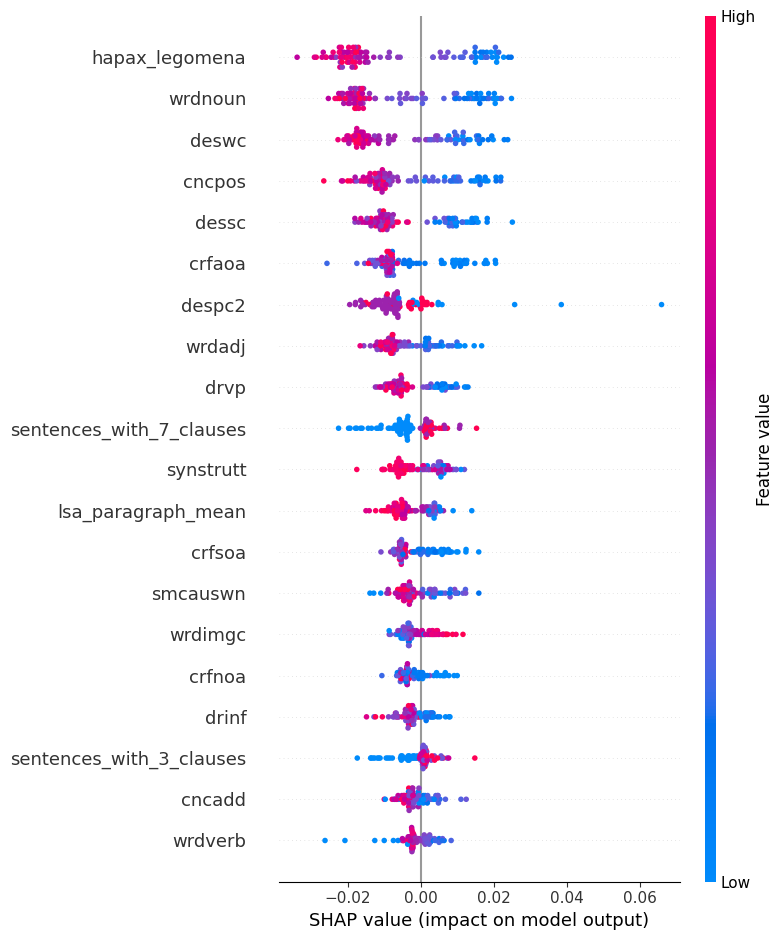

In [59]:
SAMPLE_SIZE = 100
sample_class_0 = 0
figure = plt.figure()

print("Feature Importance Plot - Global Interpretation")
print("Classe avaliada: ", class_names[class_idx])
shap.summary_plot(shap_values[:SAMPLE_SIZE,:,sample_class_0], X_test[:SAMPLE_SIZE], feature_names=feature_names)

In [68]:
X_sample = X_test[:SAMPLE_SIZE]
MAIN_FEATURES = ['hapax_legomena', 'deswc']
feat_idx1, feat_idx2 = np.where( np.isin(feature_names, np.array(MAIN_FEATURES)) )[0]
feat_idx1, feat_idx2

(43, 61)

Variable Importance Plot - Global Interpretation


<Figure size 640x480 with 0 Axes>

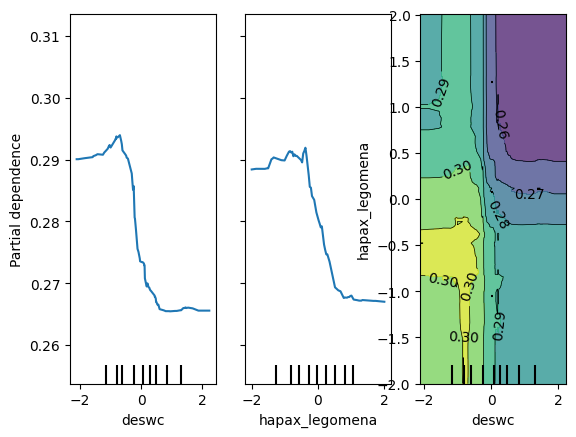

In [74]:
import matplotlib.pyplot as plt
from sklearn.inspection import PartialDependenceDisplay
print("Variable Importance Plot - Global Interpretation")
figure = plt.figure()
features = [feat_idx1, feat_idx2, (feat_idx1, feat_idx2)]
PartialDependenceDisplay.from_estimator(rf_clf, X_sample,
 features, target=Y_test[sample_class_0], feature_names=feature_names)

## Avaliando O Nível de Incerteza em Relação a Características

In [70]:
feats = {
    
}

for i in MAIN_FEATURES:
    print(i)
    feats[i] = X_test[:, np.isin(features, [i])].squeeze()

agg_uncertanty_df = pd.concat([agg_uncertanty_df, pd.DataFrame(feats).set_index(np.array([f"x{i}" for i in range(X_test.shape[0])])) ], axis=1)
agg_uncertanty_df

hapax_legomena
deswc


,Incerteza Aleatórica,Incerteza Epstêmica,hapax_legomena,deswc
x0,0.634014,0.048941,-0.112043,0.477349
x1,0.583072,0.010679,-0.774662,-0.999457
x2,0.525652,0.129017,0.119873,0.445927
x3,0.392788,0.159939,-0.708401,-0.999457
x4,0.571787,0.037486,-1.006579,-1.208933
...,...,...,...,...
x10525,0.517757,0.103747,NaN,NaN
x10526,0.557427,0.062960,NaN,NaN
x10527,0.515972,0.093288,NaN,NaN
x10528,0.467226,0.214154,NaN,NaN


<Axes: xlabel='hapax_legomena', ylabel='deswc'>

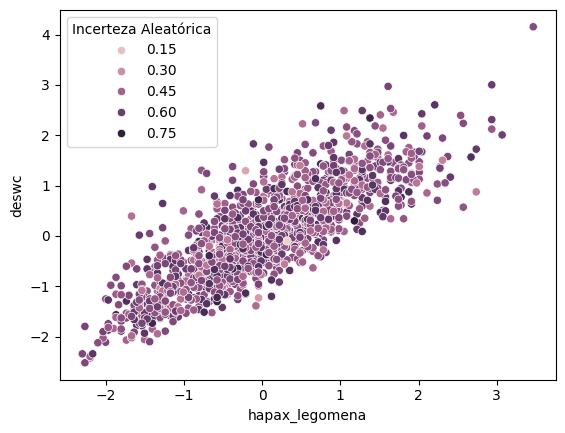

In [72]:
import seaborn as sns
sns.scatterplot(data=agg_uncertanty_df, x=MAIN_FEATURES[0], y=MAIN_FEATURES[1], hue="Incerteza Aleatórica")